## Baseline model for batching monitoring Homework!

In [1]:
import requests
import datetime
import pandas as pd
import os

from evidently import Dataset, DataDefinition, Report
from evidently.presets import DataSummaryPreset, DataDriftPreset

from joblib import load, dump
from tqdm import tqdm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\evidently\core\metric_types.py:376: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  np_bool = np.bool  # type: ignore[attr-defined]


In [ ]:
#download data from internet

#1st is for filename, 2nd is for the destination that we save
files = [('green_tripdata_2024-03.parquet', './data')]

print("Download files:")
for file, path in files:
    os.makedirs(path, exist_ok=True)
    url=f"https://d37ci6vzurychx.cloudfront.net/trip-data/{file}"
    resp=requests.get(url, stream=True)
    save_path=f"{path}/{file}"
    with open(save_path, "wb") as handle:
        for data in tqdm(resp.iter_content(),
                        desc=f"{file}",
                        postfix=f"save to {save_path}",
                        total=int(resp.headers["Content-Length"])):
            handle.write(data)

Download files:


green_tripdata_2024-03.parquet: 100%|██████████| 1372372/1372372 [00:11<00:00, 123419.70it/s, save to ./data/green_tripdata_2024-03.parquet]


In [3]:
#load data
march_data = pd.read_parquet('data/green_tripdata_2024-03.parquet')

In [4]:
march_data.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,57457.000000,57457,57457,55360.000000,57457.000000,57457.000000,55360.000000,57457.000000,57457.000000,57457.000000,57457.000000,57457.000000,57457.000000,0.0,57457.000000,57457.000000,55360.000000,55353.000000,55360.000000
mean,1.877334,2024-03-16 04:02:52.405399,2024-03-16 04:21:00.076039,1.179986,95.524688,138.629149,1.309538,13.522828,17.313474,0.904472,0.577410,2.386255,0.192537,NaN,0.979378,22.904832,1.321062,1.038047,0.737730
min,1.000000,2008-12-31 23:02:24,2008-12-31 23:02:30,1.000000,1.000000,1.000000,0.000000,0.000000,-295.080000,-2.500000,-0.500000,-1.560000,0.000000,NaN,-1.000000,-296.080000,1.000000,1.000000,-2.750000
25%,2.000000,2024-03-08 13:53:56,2024-03-08 14:13:49,1.000000,74.000000,74.000000,1.000000,1.100000,9.300000,0.000000,0.500000,0.000000,0.000000,NaN,1.000000,13.440000,1.000000,1.000000,0.000000
50%,2.000000,2024-03-15 22:49:01,2024-03-15 23:09:52,1.000000,75.000000,138.000000,1.000000,1.790000,13.500000,0.000000,0.500000,2.000000,0.000000,NaN,1.000000,18.500000,1.000000,1.000000,0.000000
75%,2.000000,2024-03-23 20:11:25,2024-03-23 20:34:48,1.000000,97.000000,220.000000,1.000000,3.100000,19.800000,1.000000,0.500000,3.610000,0.000000,NaN,1.000000,27.050000,2.000000,1.000000,2.750000
max,2.000000,2024-04-01 00:01:45,2024-04-01 16:11:00,99.000000,265.000000,265.000000,9.000000,125112.200000,841.600000,10.000000,4.250000,150.000000,26.760000,NaN,1.000000,856.980000,5.000000,2.000000,2.750000
std,0.328056,NaN,NaN,1.356719,57.285088,76.295346,0.967749,770.416255,14.958249,1.382446,0.366916,3.159273,1.184551,NaN,0.154253,17.013735,0.497858,0.191311,1.218039


## Question 1 

What's the shape of the dataset? how many rows?

Answer: 57457

In [5]:
#answer question 1
march_data.shape

(57457, 20)

In [6]:
# create target
march_data["duration_min"] = march_data.lpep_dropoff_datetime - march_data.lpep_pickup_datetime
march_data.duration_min = march_data.duration_min.apply(lambda td : float(td.total_seconds())/60)

In [7]:
# filter out outliers
march_data = march_data[(march_data.duration_min >= 0) & (march_data.duration_min <= 60)]
#duration until 1 hour or 60 minutes
march_data = march_data[(march_data.passenger_count > 0) & (march_data.passenger_count <= 8)]
#passenger start from 1 to less than 8

<Axes: >

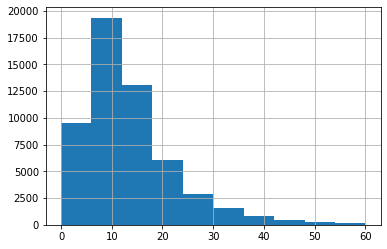

In [8]:
march_data.duration_min.hist()

In [9]:
# data labeling
target = "duration_min"
num_features = ["passenger_count", "trip_distance", "fare_amount", "total_amount"]
cat_features = ["PULocationID", "DOLocationID"]

In [10]:
march_data.shape

(54135, 21)

In [13]:
# define datasets
schema = DataDefinition(
    numerical_columns= num_features,
    categorical_columns=cat_features,
)

In [26]:
#split the data
train_data = march_data[:30000]
val_data = march_data[30000:]

In [27]:
train_data = train_data.drop(columns=["ehail_fee"], errors="ignore")
val_data = val_data.drop(columns=["ehail_fee"], errors="ignore")

In [28]:
train_dataset = Dataset.from_pandas(train_data, data_definition=schema)
val_dataset = Dataset.from_pandas(val_data, data_definition=schema)

In [29]:
#train
model = LinearRegression()
model.fit(train_data[num_features + cat_features], train_data[target])

LinearRegression()

In [30]:
train_preds = model.predict(train_data[num_features + cat_features])
train_data['prediction'] = train_preds

In [31]:
val_preds = model.predict(val_data[num_features + cat_features])
val_data['prediction'] = val_preds

In [32]:
print(mean_absolute_error(train_data.duration_min, train_data.prediction))
print(mean_absolute_error(val_data.duration_min, val_data.prediction))

3.7724732393594484
3.716814567929369


## Dump model and reference data

In [33]:
import joblib
joblib.dump(model, 'model.pkl')

['model.pkl']

In [34]:
with open('model.pkl', 'wb') as f_out:
    dump(model, f_out)

In [35]:
val_data.to_parquet('data/reference.parquet')

## Evidently report

## Question 2 Metrics

Answer: metrics that I chosed are MeanValue and MissingValue

In [23]:
from evidently.metrics import QuantileValue, MeanValue, MissingValueCount

In [36]:
report = Report(metrics=[
    DataSummaryPreset(),
    DataDriftPreset(),
    QuantileValue(column = 'fare_amount', quantile=0.5),
    MeanValue(column='fare_amount'),
    MissingValueCount(column='fare_amount')]
)

In [37]:
report.run(reference_data=train_data, current_data=val_data)

## Question 3 Monitoring

What is the maximum value of metric quantile = 0.5 on the fare_amount during March 2024? (calculated daily)

Answer: 14.2

In [52]:
# Filter March 2024 data
march_data["lpep_pickup_datetime"] = pd.to_datetime(march_data["lpep_pickup_datetime"])
# Group by day
march_data["date"] = march_data["lpep_pickup_datetime"].dt.day


In [54]:
march_data.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration_min,date
0,2,2024-03-01 00:10:52,2024-03-01 00:26:12,N,1.0,129,226,1.0,1.72,12.8,...,0.5,3.06,0.0,1.0,18.36,1.0,1.0,0.00,15.333333,1
1,2,2024-03-01 00:22:21,2024-03-01 00:35:15,N,1.0,130,218,1.0,3.25,17.7,...,0.5,0.00,0.0,1.0,20.20,2.0,1.0,0.00,12.900000,1
2,2,2024-03-01 00:45:27,2024-03-01 01:04:32,N,1.0,255,107,2.0,4.58,23.3,...,0.5,3.50,0.0,1.0,32.05,1.0,1.0,2.75,19.083333,1
3,1,2024-03-01 00:02:00,2024-03-01 00:23:45,N,1.0,181,71,1.0,0.00,22.5,...,1.5,0.00,0.0,1.0,24.00,1.0,1.0,0.00,21.750000,1
4,2,2024-03-01 00:16:45,2024-03-01 00:23:25,N,1.0,95,135,1.0,1.15,8.6,...,0.5,1.00,0.0,1.0,12.10,1.0,1.0,0.00,6.666667,1


In [55]:
march_data.drop(columns='ehail_fee', inplace=True, errors='ignore')
march_data.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration_min,date
0,2,2024-03-01 00:10:52,2024-03-01 00:26:12,N,1.0,129,226,1.0,1.72,12.8,...,0.5,3.06,0.0,1.0,18.36,1.0,1.0,0.00,15.333333,1
1,2,2024-03-01 00:22:21,2024-03-01 00:35:15,N,1.0,130,218,1.0,3.25,17.7,...,0.5,0.00,0.0,1.0,20.20,2.0,1.0,0.00,12.900000,1
2,2,2024-03-01 00:45:27,2024-03-01 01:04:32,N,1.0,255,107,2.0,4.58,23.3,...,0.5,3.50,0.0,1.0,32.05,1.0,1.0,2.75,19.083333,1
3,1,2024-03-01 00:02:00,2024-03-01 00:23:45,N,1.0,181,71,1.0,0.00,22.5,...,1.5,0.00,0.0,1.0,24.00,1.0,1.0,0.00,21.750000,1
4,2,2024-03-01 00:16:45,2024-03-01 00:23:25,N,1.0,95,135,1.0,1.15,8.6,...,0.5,1.00,0.0,1.0,12.10,1.0,1.0,0.00,6.666667,1


In [ ]:
#filter out extreme fare values
march_df = march_data[(march_data["fare_amount"] > 0) & (march_data["fare_amount"] < 100)]

# Group by date and calculate median
march_df["date"] = march_df["lpep_pickup_datetime"].dt.day
daily_medians = march_df.groupby("date")["fare_amount"].median()

# Get the max median
max_median = daily_medians.max()
print(f"🚖 Max daily median fare_amount in March 2024: {max_median}")


🚖 Max daily median fare_amount in March 2024: 14.2


In [59]:
print(daily_medians.sort_values(ascending=False).head())

date
14    14.2
3     14.2
10    14.2
24    14.0
1     13.5
Name: fare_amount, dtype: float64


## Question 4 Dashboard

I will answer /coonfig one

### Evidently Dashboard

In [67]:
march_df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration_min,date
0,2,2024-03-01 00:10:52,2024-03-01 00:26:12,N,1.0,129,226,1.0,1.72,12.8,...,0.5,3.06,0.0,1.0,18.36,1.0,1.0,0.00,15.333333,1
1,2,2024-03-01 00:22:21,2024-03-01 00:35:15,N,1.0,130,218,1.0,3.25,17.7,...,0.5,0.00,0.0,1.0,20.20,2.0,1.0,0.00,12.900000,1
2,2,2024-03-01 00:45:27,2024-03-01 01:04:32,N,1.0,255,107,2.0,4.58,23.3,...,0.5,3.50,0.0,1.0,32.05,1.0,1.0,2.75,19.083333,1
3,1,2024-03-01 00:02:00,2024-03-01 00:23:45,N,1.0,181,71,1.0,0.00,22.5,...,1.5,0.00,0.0,1.0,24.00,1.0,1.0,0.00,21.750000,1
4,2,2024-03-01 00:16:45,2024-03-01 00:23:25,N,1.0,95,135,1.0,1.15,8.6,...,0.5,1.00,0.0,1.0,12.10,1.0,1.0,0.00,6.666667,1


In [65]:
from evidently.metrics import QuantileValue, MeanValue
from evidently.presets import DataDriftPreset

from evidently.ui.workspace import Workspace

In [62]:
ws = Workspace("workspace")

In [63]:
project = ws.create_project("Homework-05 Question 4")
project.description = "My project homework descriotion"
project.save()

In [74]:
for date, group in march_data.groupby(march_data["lpep_pickup_datetime"].dt.day):
    dataset = Dataset.from_pandas(group, data_definition=schema)

    report = Report(metrics=[
        DataSummaryPreset(),
        DataDriftPreset(),
        QuantileValue(column = 'fare_amount', quantile=0.5),
        MeanValue(column='fare_amount'),
        MissingValueCount(column='fare_amount')])

    result = report.run(current_data=train_data, reference_data=val_data)



In [80]:
#  save as json
result.save_json('report.json')


In [84]:
result.save_html('report.html')

In [53]:
#add report to working space

ws.add_report(project.id, regular_report)

In [54]:
#configure the dashboard
project.dashboard.add_panel(
    DashboardPanelCounter(
        filter=ReportFilter(metadata_values={}, tag_values=[]),
        agg=CounterAgg.NONE,
        title="Homework-05 Question 4"
    )
)

project.dashboard.add_panel(
    DashboardPanelPlot(
        filter=ReportFilter(metadata_values={}, tag_values=[]),
        title="Inference Count",
        values=[
            PanelValue(
                metric_id="DatasetSummaryMetric",
                field_path="current.number_of_rows",
                legend="count"
            ),
        ],
        plot_type=PlotType.BAR,
        size=WidgetSize.HALF,
    ),
)

project.dashboard.add_panel(
    DashboardPanelPlot(
        filter=ReportFilter(metadata_values={}, tag_values=[]),
        title="Number of Missing Values",
        values=[
            PanelValue(
                metric_id="DatasetSummaryMetric",
                field_path="current.number_of_missing_values",
                legend="count"
            ),
        ],
        plot_type=PlotType.LINE,
        size=WidgetSize.HALF,
    ),
)

project.save()

Project(id=UUID('172f1d0b-f322-4848-b132-209c92f1f6d6'), name='Homework-05 Question 4', description='My project homework descriotion', dashboard=DashboardConfig(name='Homework-05 Question 4', panels=[DashboardPanelCounter(type='evidently.ui.dashboards.reports.DashboardPanelCounter', id=UUID('66492c7a-9e30-4e44-826c-5dbebd4b7d64'), title='Homework-05 Question 4', filter=ReportFilter(metadata_values={}, tag_values=[], include_test_suites=False), size=<WidgetSize.FULL: 2>, agg=<CounterAgg.NONE: 'none'>, value=None, text=None), DashboardPanelPlot(type='evidently.ui.dashboards.reports.DashboardPanelPlot', id=UUID('819f1a48-3df1-41ec-af99-8b6618955854'), title='Inference Count', filter=ReportFilter(metadata_values={}, tag_values=[], include_test_suites=False), size=<WidgetSize.HALF: 1>, values=[PanelValue(field_path='current.number_of_rows', metric_id='DatasetSummaryMetric', metric_fingerprint=None, metric_args={}, legend='count')], plot_type=<PlotType.BAR: 'bar'>), DashboardPanelPlot(type='

In [56]:
regular_report = Report(
    metrics=[
        DataQualityPreset()
    ],
    timestamp=datetime.datetime(2024,3,1)
)

regular_report.run(reference_data=None,
                  current_data=val_data.loc[val_data.lpep_pickup_datetime.between('2024-03-01', '2024-03-31', inclusive="left")],
                  column_mapping=column_mapping)

regular_report

In [57]:
ws.add_report(project.id, regular_report)